# Sociolinguistics — does the corpus record enough about its speakers to carry a paper?

The EDA notebook asks what the corpus holds and how recognisers fare on it. This one asks a
different question of the same file, `exports/analytics/analytics.jsonl` (`make export`): **is
there enough social metadata, attached to enough independent speakers, for a sociolinguistic
study of Nepali–English code-mixing?** The answer has two halves. What the corpus *records*
about a speaker is deliberately narrow: a gender and a twenty-year age bracket, typed by the
annotator from having watched the episode or set on the voice after listening to it, and a
host/guest role (D56, D58, D104). Name, dialect and origin were refused on purpose, and no model
infers anything about a speaker from audio.
What the corpus *lets you derive* is wider: who talks to whom, in what register, how the
English gets in, which address forms are used, and how each of these varies by the recorded
variables.

Eleven questions, in this order:

1. **The inventory.** What a sociolinguistic study asks of a corpus, and which of those the export records, lets you derive, or refuses.
2. **Voices, not clips.** How many independent speakers sit in each demographic cell, and for how long.
3. **Giving each voice its words.** Attributing clip text to a speaker.
4. **Code-mixing across speakers**, by gender, age, role and genre — and the confound between them.
5. **How the English gets in.** Single-word insertion, multi-word alternation, English stems with Nepali morphology, English function words.
6. **Address and honorifics.** The Nepali T/V system (*hajur / tapāī̃ / timī / tã*) by role and genre.
7. **Discourse markers**, Nepali and English, by group.
8. **Accommodation.** Does a host's mixing track the guest's, episode by episode?
9. **Turn-taking by gender pairing.**
10. **What a comparison could detect.** Minimum detectable differences at the current speaker counts.
11. **Verdict**, printed from the frames above.

Every unit of analysis below is a **voice** (an anonymous, cross-episode linked speaker, D87),
never a clip: clips of one person are not independent draws, and a paper's n is its speakers.
The notebook runs no model. Everything comes from the reference transcripts and the metadata.

In [1]:
import json
import re
import sys
import warnings
from collections import Counter, defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

warnings.filterwarnings("ignore", category=FutureWarning)

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
ANALYTICS = REPO / "exports" / "analytics" / "analytics.jsonl"
FIGURES = REPO / "notebooks" / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

# Same palette as 01_EDA.ipynb: the first three slots of the reference categorical palette, one
# blue ramp for anything ordered, grey for the unknown.
SLOTS = ["#2a78d6", "#eb6834", "#1baf7a"]
SPLITS = ["train", "val", "gold"]
GENDERS = ["female", "male"]
GENDER_COLOR = {"female": "#2a78d6", "male": "#eb6834", "unresolved": "#b9b7b0", "mixed": "#1baf7a"}
AGE_ORDER = ["under_20", "20_39", "40_59", "60_79", "80_plus"]
ROLES = ["host", "guest"]
ROLE_COLOR = {"host": "#2a78d6", "guest": "#eb6834"}
RAMP = ["#86b6ef", "#5598e7", "#2a78d6", "#1c5cab", "#0d366b"]
GREY = "#b9b7b0"
INK, MUTED = "#0b0b0b", "#52514e"

plt.style.use("default")
plt.rcParams.update({
    "font.size": 9.5, "axes.titlesize": 10.5, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.edgecolor": "#c9c8c2", "axes.labelcolor": MUTED, "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.grid": True, "grid.color": "#ecebe7", "grid.linewidth": 0.8, "axes.axisbelow": True,
    "axes.spines.top": False, "axes.spines.right": False, "figure.dpi": 110, "legend.frameon": False,
})
_installed = {f.name for f in plt.matplotlib.font_manager.fontManager.ttflist}
DEVA_FONT = next((n for n in ("Noto Sans Devanagari", "Noto Serif Devanagari", "FreeSans") if n in _installed), None)


def script_aware(texts):
    """Give labels that contain Devanagari a font list that can draw both scripts."""
    for text in texts:
        if DEVA_FONT and re.search(r"[ऀ-ॿ]", text.get_text()):
            text.set_fontfamily(["DejaVu Sans", DEVA_FONT])
    return texts


def save(fig, name):
    fig.savefig(FIGURES / f"socio_{name}.png", dpi=150, bbox_inches="tight")


def pretty(v):
    """``20_39`` reads as a range, ``talk_show`` as two words."""
    return re.sub(r"(?<=\d)_(?=\d)", "-", str(v)).replace("_", " ")


pd.set_option("display.width", 180)
pd.set_option("display.max_columns", 40)
pd.set_option("display.max_rows", 140)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

manifest = json.loads((ANALYTICS.parent / "manifest.json").read_text())
rows, EP_META, talk, WHO, ROLE = [], {}, {}, {}, {}
with ANALYTICS.open(encoding="utf-8") as fh:
    for line in fh:
        r = json.loads(line)
        meta = r["episode_metadata"] or {}
        cls = r["classes"]
        vad = r["vad_spans"] or []
        per_voice = defaultdict(float)
        for t in r["speaker_turns"] or []:
            if t["voice"]:
                per_voice[t["voice"]] += t["end"] - t["start"]
                # Who the voice is, as the harness resolves it (D107): one gender and age per
                # voice, one role per voice and episode.
                WHO[t["voice"]] = (t["gender"], t["age_bracket"])
                if t["role"]:
                    ROLE[(r["episode_id"], t["voice"])] = t["role"]
        talk[r["segment_id"]] = dict(per_voice)
        rows.append({
            "segment_id": r["segment_id"], "episode": r["episode_id"],
            "split": "gold" if r["pot"] == "gold" else r["split"],
            "tier": r["verification_tier"], "disposition": r["disposition"],
            "duration": r["duration_seconds"], "speech_s": sum(b - a for a, b in vad),
            "genre": meta.get("genre") or "unclassified", "topic": meta.get("topic") or "unclassified",
            "declared": len(meta.get("speakers") or {}),
            "overlap_s": sum(b - a for a, b in r["overlap_spans"]),
            "turn_changes": max(0, len(r["speaker_turns"] or []) - 1),
            "voice": None if cls["voice"] == "unlinked" else cls["voice"],
            "c_speakers": cls["speakers"], "c_gender": cls["gender"], "c_age": cls["age_bracket"],
            "text": r["text"] or "",
        })
        EP_META.setdefault(r["episode_id"], meta)

seg = pd.DataFrame(rows).set_index("segment_id")
usable = seg[seg.disposition.isin(["accepted_unchanged", "edited"]) & (seg.text.str.len() > 0)].copy()
# Genre is a closed list of recording formats (D102), more of them than colours that stay apart:
# a genre is read off its row, largest first, and every genre is drawn in the one colour.
GENRES = usable.groupby("genre").duration.sum().sort_values(ascending=False).index.tolist()
GENRE_COLOR = dict.fromkeys(GENRES, SLOTS[0])
# The age brackets some voice has, youngest first.
AGES = [a for a in AGE_ORDER if a in {age for _, age in WHO.values()}]
print(f"{len(seg):,} labeled clips, {seg.duration.sum() / 3600:.2f} h, {seg.episode.nunique()} episodes | exported "
      f"{manifest['exported_at'][:10]} at harness {manifest['git_commit'][:7]}")
print(f"{len(usable):,} clips with an accepted, non-empty reference are the material below")

17,659 labeled clips, 61.17 h, 342 episodes | exported 2026-09-30 at harness 06fd762
17,591 clips with an accepted, non-empty reference are the material below


## 1. The inventory

What a sociolinguistic study of code-mixing conventionally wants to condition on, against what
the export carries. **Recorded** is typed at ingest; **derived** is computed here from the
transcript, the diarizer's turns or the episode's structure; **stored** is in the harness but
not in the export this notebook reads; **refused** was removed on purpose
and will not come back (D56: a name is a join key to a dossier, a dialect label the owner cannot
place reliably is a wrong stratification variable rather than a missing one); **absent** is
simply not collected and could be, since none of it identifies a person. Coverage is computed
in section 2 once voices are resolved, and quoted again in the verdict.

In [2]:
INVENTORY = pd.DataFrame([
    ("speaker gender", "recorded", "set on the voice by ear (D104), else the episode's declared rows where they force it (D58, D91)", "per voice (sec. 2)"),
    ("speaker age", "recorded", "twenty-year bracket, by ear or from the declared rows, as gender", "same"),
    ("role in the recording", "recorded", "host / guest per declared speaker, where the rows force which voice it is (D91)", "per voice and episode"),
    ("interlocutor", "derived", "the other voices in the episode, and their gender/age when resolved", "sec. 9"),
    ("register / genre", "recorded", "the recording's format, from a closed list (D102); chosen at ingest, editable afterwards", "every clip"),
    ("topic", "recorded", "closed taxonomy, LLM-classified from the transcript (D57)", "every clip"),
    ("series / show", "derived", "read off the episode id, for the three podcast series it names", "those series' episodes"),
    ("speaking rate, pauses, overlap, hand-overs", "derived", "VAD, overlap detector and diarizer spans (D77, D78)", "every clip"),
    ("code-mixing measures", "derived", "script of every reference token: share, switch points, run lengths, integrated stems", "every clip with text"),
    ("address forms / honorific level", "derived", "second-person pronouns in the reference", "every clip with text"),
    ("discourse markers", "derived", "closed lists, Nepali and English", "every clip with text"),
    ("dialect / region / origin", "refused", "D56: the owner cannot label Nepali dialect reliably; a guessed grouping variable biases everything computed over it", "none"),
    ("name / identity", "refused", "D56", "none"),
    ("education, occupation, class", "absent", "not on the ingest form; could be added as coarse public-profile facts", "none"),
    ("first language, ethnicity, caste", "absent", "not collected; sensitive, and not observable from an episode", "none"),
    ("years abroad / diaspora status", "absent", "not collected", "none"),
    ("upload date, channel", "stored", "kept by the harness per episode (published_at, show_id) but not written to the export", "none here"),
    ("audience size", "absent", "not collected; non-personal and cheap to add at ingest", "none"),
    ("speaker's own language attitudes", "absent", "needs a questionnaire, not a corpus", "none"),
], columns=["variable", "status", "how", "coverage"]).set_index("variable")
display(INVENTORY)

,status,how,coverage
variable,,,
speaker gender,recorded,"set on the voice by ear (D104), else the episo...",per voice (sec. 2)
speaker age,recorded,"twenty-year bracket, by ear or from the declar...",same
role in the recording,recorded,"host / guest per declared speaker, where the r...",per voice and episode
interlocutor,derived,"the other voices in the episode, and their gen...",sec. 9
register / genre,recorded,"the recording's format, from a closed list (D1...",every clip
topic,recorded,"closed taxonomy, LLM-classified from the trans...",every clip
series / show,derived,"read off the episode id, for the three podcast...",those series' episodes
"speaking rate, pauses, overlap, hand-overs",derived,"VAD, overlap detector and diarizer spans (D77,...",every clip
code-mixing measures,derived,"script of every reference token: share, switch...",every clip with text


## 2. Voices, not clips

**Method.** pyannote diarizes every episode at its declared speaker count (D79); embeddings are
linked across episodes into anonymous voices (D87). Who a voice is comes with the export, on
every turn, resolved once by the harness for its voices page (D107):

- **gender and age** belong to the person. The owner listened to the voices and set both by ear
  (D104); a voice not set that way takes what its episodes' declared rows force (one row and
  one voice; the one recurring voice of an episode that declares one host; rows that all share
  the value, D91). A value set by ear outranks the rows.
- **role** belongs to the recording, so it is per voice and episode and comes from the declared
  rows alone. A voice's role here is the one its episodes agree on.

Nothing is inferred by a model, and a voice nothing reached stays unresolved rather than guessed.
A voice's genre is where most of its talk time is, since cross-episode linking can place a voice
in a stray episode of another genre.

In [3]:
voice_talk, voice_eps, voice_genre = defaultdict(float), defaultdict(set), defaultdict(Counter)
for sid, per in talk.items():
    if sid in usable.index:
        for v, sec in per.items():
            voice_talk[v] += sec
            voice_eps[v].add(usable.episode[sid])
            voice_genre[v][usable.genre[sid]] += sec
VOICES = sorted(voice_talk)
n_eps = {v: len(voice_eps[v]) for v in VOICES}


def agree(values):
    vals = {v for v in values if v}
    return vals.pop() if len(vals) == 1 else "unresolved"


SERIES = (("on_air_with_sanjay_", "On Air with Sanjay"), ("the_bravo_delta_show_", "Bravo Delta Show"))


def show(ep_id):
    """The series an episode id names, or the episode's genre when it names none."""
    for prefix, name in SERIES:
        if ep_id.startswith(prefix):
            return name
    if re.match(r"ep_\d+_", ep_id):
        return "ep_NNN podcast"
    return pretty(EP_META[ep_id].get("genre") or "unclassified")


usable["show"] = usable.episode.map(show)
SPK = pd.DataFrame([{
    "voice": v, "episodes": n_eps[v], "talk_min": voice_talk[v] / 60,
    "gender": WHO[v][0] or "unresolved",
    "age": WHO[v][1] or "unresolved",
    "role": agree(ROLE.get((e, v)) for e in voice_eps[v]),
    "genre": voice_genre[v].most_common(1)[0][0],  # where most of the voice's talk time is
    "show": ", ".join(sorted({show(e) for e in voice_eps[v]})),
} for v in VOICES]).set_index("voice").sort_values("talk_min", ascending=False)

tot = SPK.talk_min.sum()
print(f"{len(SPK)} voices, {tot / 60:.1f} h of diarized speech")
for f in ("gender", "age", "role"):
    known = SPK[f] != "unresolved"
    print(f"  {f:<7} known for {known.sum():>3} voices ({known.mean():.0%}) holding {SPK.talk_min[known].sum() / tot:.0%} of the speech")
cell = SPK[(SPK.gender != "unresolved") & (SPK.age != "unresolved")]
grid = pd.DataFrame({
    "voices": cell.groupby(["gender", "age"]).size(),
    "voices 5+ min": cell[cell.talk_min >= 5].groupby(["gender", "age"]).size(),
    "minutes": cell.groupby(["gender", "age"]).talk_min.sum(),
    "median min / voice": cell.groupby(["gender", "age"]).talk_min.median(),
}).fillna(0).reindex(pd.MultiIndex.from_product([GENDERS, AGES], names=["gender", "age"]), fill_value=0)
grid = grid.astype({"voices": int, "voices 5+ min": int})
display(grid)

358 voices, 57.1 h of diarized speech
  gender  known for 357 voices (100%) holding 100% of the speech
  age     known for 357 voices (100%) holding 100% of the speech
  role    known for 137 voices (38%) holding 73% of the speech


voices  voices 5+ min  minutes  median min / voice
gender age                                                         
female under_20       2              0     0.33                0.17
       20_39         66             17   548.22                1.03
       40_59         21              7   298.82                2.03
       60_79          2              2    50.51               25.26
       80_plus        0              0     0.00                0.00
male   under_20       1              1    12.43               12.43
       20_39        166             56 1,454.87                1.94
       40_59         77             27   732.94                2.32
       60_79         17             13   249.61               12.21
       80_plus        5              4    77.34               14.98

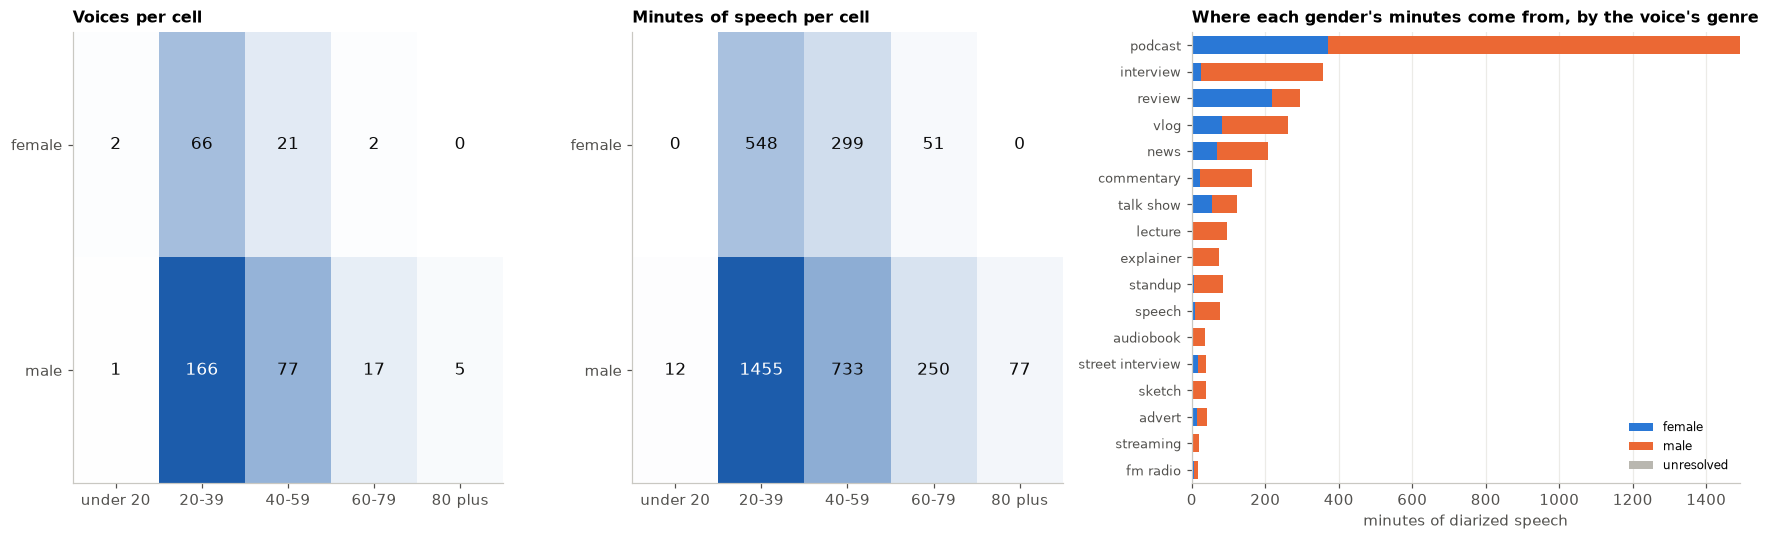

female speech: podcast holds 41% of it. Women hold 26% of the speech whose gender is known, from 0% (lecture) to 74% (review) across the 15 genres with 30+ such minutes: gender is confounded with genre, so every gender comparison below is also a genre comparison unless it is made within one genre.


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), gridspec_kw={"width_ratios": [1.1, 1.1, 1.4]})
for ax, col, title in ((axes[0], "voices", "Voices per cell"), (axes[1], "minutes", "Minutes of speech per cell")):
    m = grid[col].unstack("age").reindex(GENDERS).reindex(columns=AGES)
    ax.imshow(m.to_numpy(), cmap=plt.matplotlib.colors.LinearSegmentedColormap.from_list("blue", ["#ffffff", RAMP[3]]), aspect="auto")
    for i, g in enumerate(GENDERS):
        for j, a in enumerate(AGES):
            v = m.loc[g, a]
            ax.text(j, i, f"{v:.0f}", ha="center", va="center", fontsize=11, color="white" if v > m.to_numpy().max() * 0.6 else INK)
    ax.set_xticks(range(len(AGES)), [pretty(a) for a in AGES])
    ax.set_yticks(range(len(GENDERS)), GENDERS)
    ax.set(title=title)
    ax.grid(False)

ax = axes[2]
by_genre = SPK.groupby(["genre", "gender"]).talk_min.sum().unstack(fill_value=0)
by_genre = by_genre.reindex([g for g in GENRES if g in by_genre.index]).reindex(columns=["female", "male", "unresolved"], fill_value=0)
left = np.zeros(len(by_genre))
for g in by_genre.columns:
    ax.barh(range(len(by_genre)), by_genre[g], left=left, color=GENDER_COLOR[g], label=g, height=0.68)
    left += by_genre[g].to_numpy()
ax.set_yticks(range(len(by_genre)), [pretty(g) for g in by_genre.index], fontsize=8.5)
ax.set_ylim(len(by_genre) - 0.5, -0.5)
ax.set(title="Where each gender's minutes come from, by the voice's genre", xlabel="minutes of diarized speech")
ax.grid(axis="y", visible=False)
ax.legend(fontsize=8, loc="lower right")
fig.tight_layout()
save(fig, "01_voices_by_cell")
plt.show()
f_share = by_genre["female"] / by_genre["female"].sum()
known_min = by_genre[["female", "male"]]
f_in = (known_min.female / known_min.sum(axis=1))[known_min.sum(axis=1) >= 30]
print(f"female speech: {pretty(f_share.idxmax())} holds {f_share.max():.0%} of it. Women hold {known_min.female.sum() / known_min.to_numpy().sum():.0%} of the "
      f"speech whose gender is known, from {f_in.min():.0%} ({pretty(f_in.idxmin())}) to {f_in.max():.0%} ({pretty(f_in.idxmax())}) across the {len(f_in)} genres "
      f"with 30+ such minutes: gender is confounded with genre, so every gender comparison below is also a genre comparison unless it is made within one genre.")

## 3. Giving each voice its words

A clip's reference is one string, but a clip may hold two people. A clip's text is credited to a
voice only when that voice holds at least 90% of the clip's diarized talk; anything more shared
is left out of every per-voice measure. Tokens are the whitespace words of the reference with
edge punctuation removed, classified by script: **Devanagari** (Nepali), **Latin** (English),
**mixed** (a Latin stem carrying Devanagari morphology, *phoneमा*, *photosहरू*), numerals and
other. Fillers are kept, since *uh* versus *अँ* is itself a choice. Sentences are split on the
danda and on `.?!`.

In [5]:
DEV = re.compile(r"[ऀ-ॿ]")
LAT = re.compile(r"[A-Za-z]")
NUM = re.compile(r"^[0-9०-९.,%]+$")
EDGE = ".,;:!?।\"'()[]{}“”‘’-–—…"
SENT_END = re.compile(r"[।.?!]+")

EN_FUNCTION = set("""the a an is are was were be been being am to of and or but in on at for with that this these
those it its i you we they he she my your our their his her me us them not no do does did have has had will would
can could should shall may might if then so because what which who whom how there here as from by about just very
than too also any some all more most much many such there's it's that's i'm you're we're they're don't doesn't didn't
can't won't isn't aren't wasn't""".split())
EN_FILLER = {"uh", "um", "hmm", "mm", "ah", "er"}
HONORIFIC = {"high": ("तपाईं", "तपाई", "तपाईँ", "हजुर"), "mid": ("तिमी", "तिम्र"), "low": ("तँ", "तेर", "तैं", "तैँ")}
DM_NE = {"चाहिँ": "chāhī̃", "चैँ": "chāhī̃", "नि": "ni", "है": "hai", "अनि": "ani", "हैन": "haina", "भनेको": "bhaneko",
         "भन्या": "bhaneko", "मतलब": "matlab", "खै": "khai", "ल": "la"}
DM_EN = {"so", "like", "actually", "basically", "okay", "ok", "right", "yeah", "literally", "obviously", "anyway"}
DM_EN_BIGRAM = {("you", "know"), ("i", "mean")}


def sentences(text):
    out = []
    for sent in SENT_END.split(text):
        toks = []
        for w in sent.split():
            w = w.strip(EDGE)
            if not w:
                continue
            d, l = bool(DEV.search(w)), bool(LAT.search(w))
            toks.append((w, "mixed" if d and l else "dev" if d else "lat" if l else "num" if NUM.match(w) else "other"))
        if toks:
            out.append(toks)
    return out


def features(text):
    f = Counter()
    for sent in sentences(text):
        lex = [(w, c) for w, c in sent if c in ("dev", "lat", "mixed")]
        if not lex:
            continue
        kinds = {c for _, c in lex}
        f["sentences"] += 1
        f["s_nepali" if kinds == {"dev"} else "s_english" if "dev" not in kinds else "s_mixed"] += 1
        prev, run = None, 0
        for w, c in lex:
            f[c] += 1
            side = "en" if c != "dev" else "ne"
            if prev and side != prev:
                f["switches"] += 1
            if side == "en":
                run += 1
            elif run:
                if "dev" in kinds:
                    f[f"run_{min(run, 6)}"] += 1
                    f[f"run_tok_{min(run, 6)}"] += run
                run = 0
            prev = side
            lw = w.lower()
            if c == "lat":
                f["en_function"] += lw in EN_FUNCTION
                f["en_filler"] += lw in EN_FILLER
                f["dm_en"] += lw in DM_EN
                f["en_you"] += lw in ("you", "your", "yours", "you're")
            elif c == "dev":
                f["ne_filler"] += w in ("अँ", "अ", "ऊँ")
                for level, prefixes in HONORIFIC.items():
                    if w.startswith(prefixes):
                        f[f"hon_{level}"] += 1
                        f["hajur_bare"] += w == "हजुर"
                if w in DM_NE:
                    f["dm_ne"] += 1
                    f[f"dmne_{DM_NE[w]}"] += 1
        if run and "dev" in kinds:
            f[f"run_{min(run, 6)}"] += 1
            f[f"run_tok_{min(run, 6)}"] += run
        low = [w.lower() for w, c in lex]
        f["dm_en"] += sum((a, b) in DM_EN_BIGRAM for a, b in zip(low, low[1:]))
    f["tokens"] = f["dev"] + f["lat"] + f["mixed"]
    return dict(f)


feat = pd.DataFrame([features(t) for t in usable.text], index=usable.index).fillna(0).astype(int)
usable = usable.join(feat)
usable = usable[usable.tokens > 0]

dominant = {}
for sid, per in talk.items():
    if per and sid in usable.index:
        v, s = max(per.items(), key=lambda kv: kv[1])
        if s / sum(per.values()) >= 0.9:
            dominant[sid] = v
usable["speaker"] = pd.Series(dominant).reindex(usable.index)
attributed = usable[usable.speaker.notna()].copy()
for f in ("gender", "age", "role"):
    attributed[f] = attributed.speaker.map(SPK[f])

print(f"{len(usable):,} clips, {usable.tokens.sum():,} tokens ({usable.dev.sum() / usable.tokens.sum():.0%} Devanagari, "
      f"{usable.lat.sum() / usable.tokens.sum():.0%} Latin, {usable.mixed.sum() / usable.tokens.sum():.1%} mixed-script)")
print(f"{len(attributed):,} clips ({len(attributed) / len(usable):.0%}) and {attributed.tokens.sum() / usable.tokens.sum():.0%} of tokens "
      f"are credited to one voice; the rest are shared clips and stay out of per-voice measures")
print(f"sentences: {usable.s_nepali.sum() / usable.sentences.sum():.0%} Nepali only, {usable.s_mixed.sum() / usable.sentences.sum():.0%} mixed "
      f"within the sentence, {usable.s_english.sum() / usable.sentences.sum():.0%} English only")

COUNTS = [c for c in feat.columns]
V = attributed.groupby("speaker")[COUNTS].sum()
V = V.join(SPK[["talk_min", "episodes", "gender", "age", "role", "genre", "show"]])
V["english %"] = 100 * (V.lat + V.mixed) / V.tokens
V["switches / 100"] = 100 * V.switches / V.tokens
V["integrated / 1000"] = 1000 * V.mixed / V.tokens
V["en function %"] = 100 * V.en_function / V.lat.clip(lower=1)
V["single-word %"] = 100 * V.run_tok_1 / sum(V[f"run_tok_{k}"] for k in range(1, 7)).clip(lower=1)
V["long-run %"] = 100 * V.run_tok_6 / sum(V[f"run_tok_{k}"] for k in range(1, 7)).clip(lower=1)
V["en sentences %"] = 100 * V.s_english / V.sentences
for level in ("high", "mid", "low"):
    V[f"hon {level} / 1000"] = 1000 * V[f"hon_{level}"] / V.tokens
V["you / 1000"] = 1000 * V.en_you / V.tokens
V["dm ne / 1000"] = 1000 * V.dm_ne / V.tokens
V["dm en / 1000"] = 1000 * V.dm_en / V.tokens
V["en dm share %"] = 100 * V.dm_en / (V.dm_ne + V.dm_en).clip(lower=1)
V["rate w/s"] = attributed.groupby("speaker").tokens.sum() / attributed.groupby("speaker").speech_s.sum().clip(lower=1)
MIN_TOKENS = 300
VV = V[V.tokens >= MIN_TOKENS].copy()
# A genre is a group of voices only when three or more of them have most of their talk in it.
GENRE_GROUPS = [g for g in GENRES if (VV.genre == g).sum() >= 3]
print(f"{len(V)} voices carry attributed text; {len(VV)} have {MIN_TOKENS}+ tokens and are the units of every comparison below "
      f"(gender known for {(VV.gender != 'unresolved').sum()}, age {(VV.age != 'unresolved').sum()}, role {(VV.role != 'unresolved').sum()})")
print(f"{len(GENRE_GROUPS)} of {len(GENRES)} genres hold 3+ of those voices: " + ", ".join(f"{pretty(g)} {(VV.genre == g).sum()}" for g in GENRE_GROUPS))

17,591 clips, 594,892 tokens (77% Devanagari, 23% Latin, 0.5% mixed-script)
14,214 clips (81%) and 76% of tokens are credited to one voice; the rest are shared clips and stay out of per-voice measures
sentences: 43% Nepali only, 50% mixed within the sentence, 7% English only
294 voices carry attributed text; 171 have 300+ tokens and are the units of every comparison below (gender known for 171, age 171, role 105)
14 of 17 genres hold 3+ of those voices: podcast 48, interview 23, review 7, vlog 19, news 8, commentary 6, talk show 7, lecture 9, explainer 13, standup 7, speech 8, sketch 4, advert 5, streaming 3


## 4. Code-mixing across speakers

Every dot is a voice with 300+ attributed tokens; the bar is the group median. The tests are
Mann–Whitney (two groups) or Kruskal–Wallis (three) on the voice-level values, which is the
right unit but a blunt instrument at these counts: read the n before the p. A genre is compared
only when three or more such voices have most of their talk time in it; the others never appear
as a group. The last two panels are the confound: the same gender and age splits inside the
podcasts alone, where genre is held fixed. Older voices sit in the interviews, speeches and news,
which are nearly all Nepali, so a difference by age over the whole corpus is a difference by genre
until it is seen inside one.

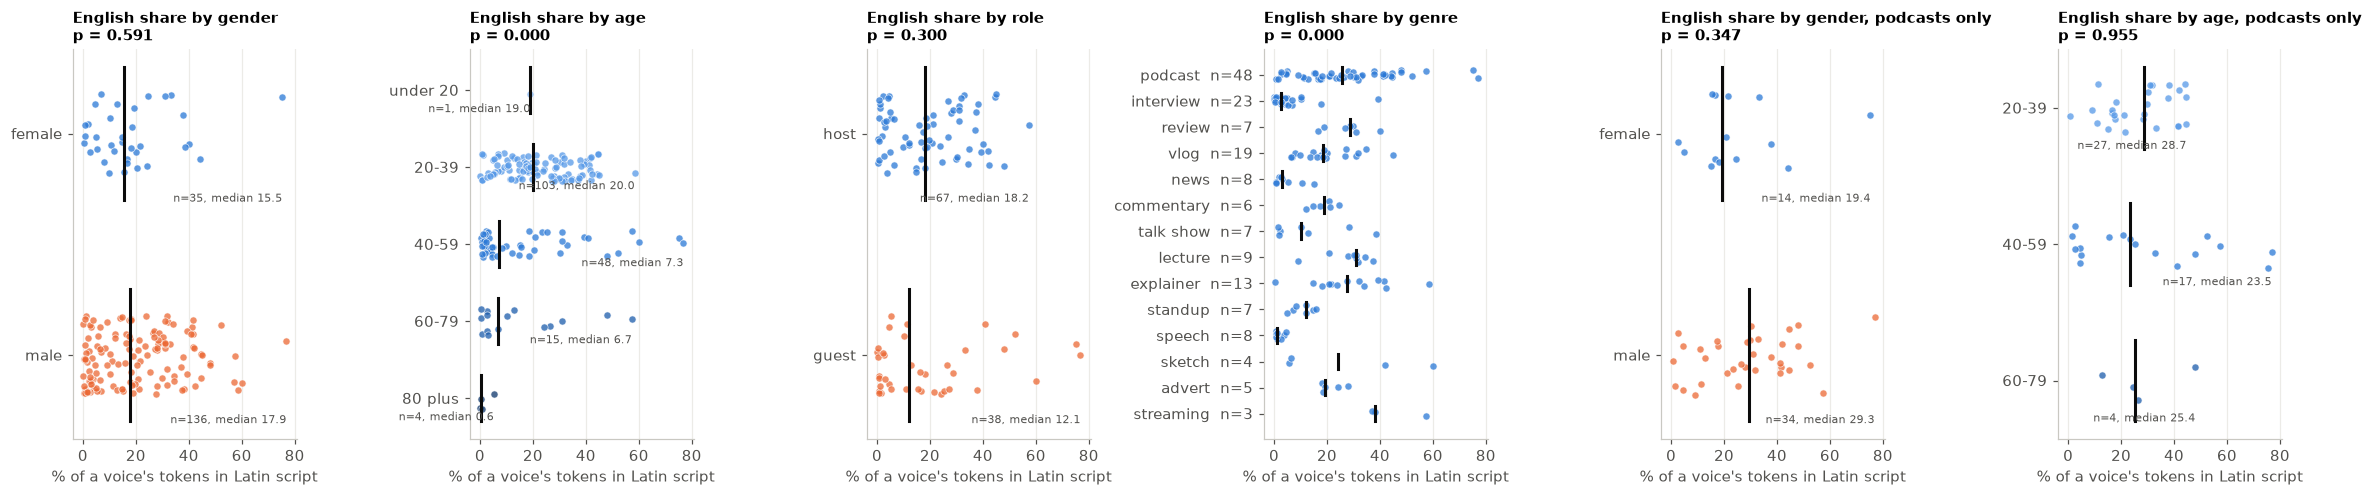

voices  minutes  english %  switches / 100  integrated / 1000  single-word %  long-run %  en function %  rate w/s
comparison               group                                                                                                                        
by gender                female       35.00   834.08      15.47           16.45               3.45          49.58        0.00           9.38      2.59
                         male        136.00 2,395.17      17.95           19.12               2.54          47.02        3.02           7.61      2.78
                         p              NaN      NaN       0.59            0.96               0.59           0.32        0.16           0.53      0.19
by age                   20_39       103.00 1,881.72      20.04           23.75               3.63          44.87        4.27           9.65      2.88
                         40_59        48.00   962.45       7.33            7.56               1.48          48.18        0.00           7.83      2.46
                         60_79        15.00   297.24       6.66            6.63               0.68          57.69        0.00           2.22      2.55
                         80_plus       4.00    75.41       0.55            1.10               0.16         100.00        0.00           0.00      2.22
                         p              NaN      NaN       0.00            0.00               0.00           0.00        0.22           0.06      0.00
by role                  host         67.00 1,693.57      18.16           17.93               3.00          47.06        3.66           7.87      2.64
                         guest        38.00   762.91      12.13           11.59               1.08          49.79        0.00           8.49      2.54
                         p              NaN      NaN       0.30            0.07               0.02           0.32        0.44           0.87      0.45
by genre                 podcast      48.00 1,467.72      25.82           21.43               4.33          39.74       10.43          19.98      2.85
                         interview    23.00   349.36       2.77            5.12               0.31          68.42        0.00           0.00      2.45
                         review        7.00   293.36      28.54           24.03               4.86          32.43        3.60           5.39      2.79
                         vlog         19.00   238.92      18.44           22.65               3.27          48.25        3.95           9.62      3.02
                         news          8.00   197.70       2.93            3.68               1.16          49.73        0.00           0.27      2.32
                         commentary    6.00   165.13      19.02           26.23               6.87          55.69        0.97           2.74      2.97
                         talk_show     7.00    73.35      10.10           15.27               0.00          58.33        0.00           5.59      2.74
                         lecture       9.00    95.19      30.96           28.14               5.04          38.52        9.09          13.78      2.69
                         explainer    13.00    65.93      27.46           30.75               5.07          35.84        0.00           5.56      2.97
                         standup       7.00    83.25      11.91           14.26               1.06          62.26        0.00           6.43      2.39
                         speech        8.00    74.85       1.08            1.81               0.11          72.56        0.00           2.17      2.41
                         sketch        4.00    34.71      24.20            7.98               4.51          41.60        7.14          33.42      2.33
                         advert        5.00    11.34      19.23           25.10               6.80          49.30        0.00           7.25      3.12
                         streaming     3.00    19.97      38.07           14.46               4.82          24.

In [6]:
def strip(ax, frame, col, by, order, colors, title=None, xlabel=None, min_n=1, compact=False):
    """One row of dots per group, with its median. ``compact`` is for many rows: the n moves into
    the row's label, where it cannot land on the next row's dots."""
    rng = np.random.default_rng(0)
    groups = [(g, frame.loc[frame[by] == g, col].dropna()) for g in order]
    groups = [(g, s) for g, s in groups if len(s) >= min_n]
    for i, (g, s) in enumerate(groups):
        ax.scatter(s, i + rng.uniform(-0.18, 0.18, len(s)), s=22, color=colors.get(g, GREY), alpha=0.75, edgecolor="white", linewidth=0.5)
        ax.plot([s.median(), s.median()], [i - 0.3, i + 0.3], color=INK, lw=2)
        if not compact:
            ax.text(s.max(), i + 0.32, f"n={len(s)}, median {s.median():.1f}", fontsize=7.5, color=MUTED, ha="right", va="bottom")
    ax.set_yticks(range(len(groups)), [f"{pretty(g)}  n={len(s)}" if compact else pretty(g) for g, s in groups])
    ax.set(title=title or col, xlabel=xlabel or col)
    ax.grid(axis="y", visible=False)
    ax.invert_yaxis()
    return groups


def test(frame, col, by, order):
    groups = [frame.loc[frame[by] == g, col].dropna() for g in order if (frame[by] == g).sum() >= 3]
    if len(groups) < 2:
        return np.nan
    return (stats.mannwhitneyu(*groups).pvalue if len(groups) == 2 else stats.kruskal(*groups).pvalue)


pod = VV[VV.genre == "podcast"]
AGE_COLOR = dict(zip(AGES, RAMP[-len(AGES):]))
panels = [("gender", GENDERS, GENDER_COLOR, VV, "by gender"), ("age", AGES, AGE_COLOR, VV, "by age"),
          ("role", ROLES, ROLE_COLOR, VV, "by role"), ("genre", GENRE_GROUPS, GENRE_COLOR, VV, "by genre"),
          ("gender", GENDERS, GENDER_COLOR, pod, "by gender, podcasts only"), ("age", AGES, AGE_COLOR, pod, "by age, podcasts only")]
fig, axes = plt.subplots(1, 6, figsize=(21, 4.6), sharex=True)
for ax, (by, order, colors, frame, title) in zip(axes, panels):
    strip(ax, frame, "english %", by, order, colors, title=f"English share {title}", xlabel="% of a voice's tokens in Latin script",
          compact=by == "genre")
    ax.set_title(f"English share {title}\np = {test(frame, 'english %', by, order):.3f}", fontsize=9.5)
fig.tight_layout()
save(fig, "02_mixing_by_group")
plt.show()

METRICS = ["english %", "switches / 100", "integrated / 1000", "single-word %", "long-run %", "en function %", "rate w/s"]
tab = {}
for by, order, _, frame, title in panels:
    for g in order:
        sub = frame[frame[by] == g]
        if len(sub) >= 3:
            tab[(title, g)] = {"voices": len(sub), "minutes": sub.talk_min.sum(), **{m: sub[m].median() for m in METRICS}}
    tab[(title, "p")] = {m: test(frame, m, by, order) for m in METRICS}
tab = pd.DataFrame(tab).T
tab.index.names = ["comparison", "group"]
display(tab.round(2))

## 5. How the English gets in

Three readings that a paper on mixing would want, each of which the transcript supports:

- **Insertion vs alternation** (Muysken's distinction): inside a mixed sentence, how long is a
  stretch of English? A single English word sitting in a Nepali clause is a lexical insertion;
  six or more in a row is a switch into English syntax. The share of English tokens that sit in
  each run length says which of the two this corpus mostly is.
- **Morphological integration**: an English stem taking Nepali plural or case morphology
  (*phonesहरूको*, *Chinaमा*) is the clearest sign of a borrowing that has entered the Nepali
  grammar. The most frequent such tokens are listed, with the Nepali suffixes they take.
- **English function words** as a share of a voice's English: a speaker who inserts nouns has
  almost none; a speaker who switches into English clauses carries *the, is, to, and* with them.

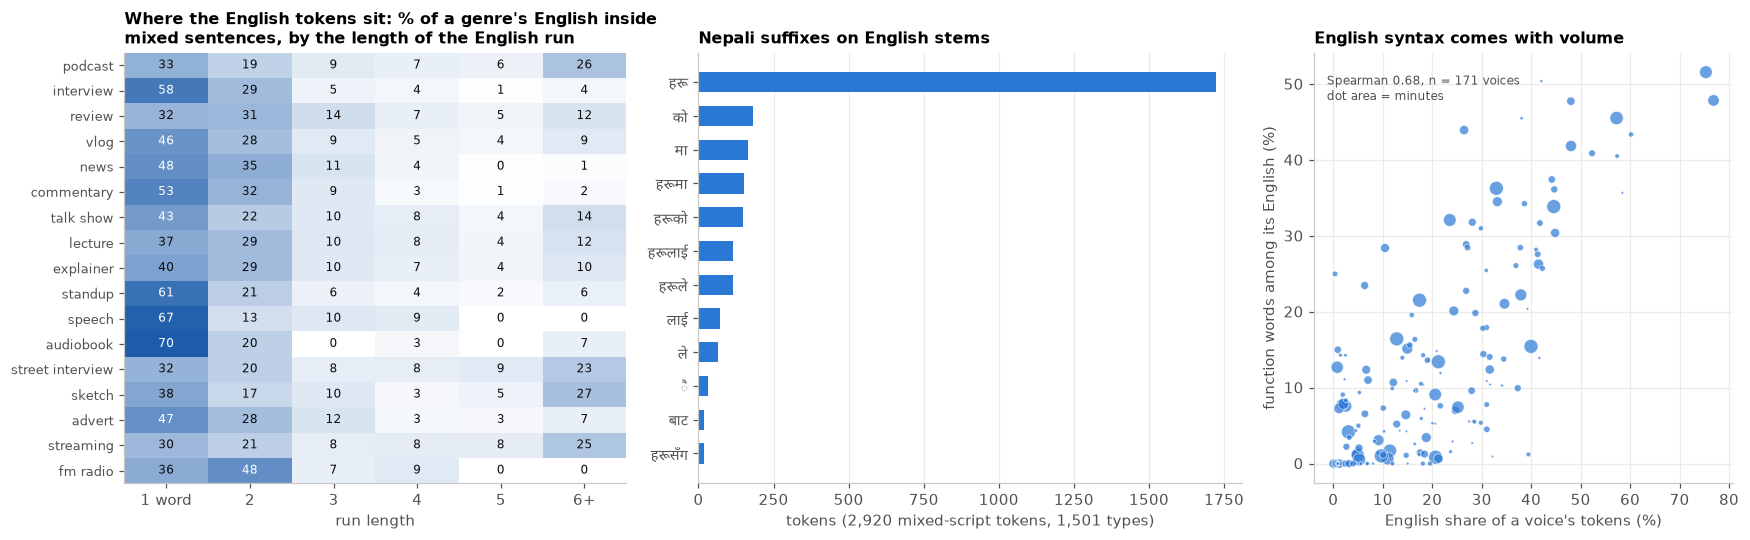

most frequent integrated stems: phoneको (83), phoneमा (57), videoमा (40), photosहरू (30), videoहरू (29), phonesहरू (28), foodहरू (28), companyको (22), lastै (20), companyले (19), questionहरू (19), Americaमा (17), portraitsहरू (17), phonesहरूमा (17), phoneहरू (16)
37% of the English inside mixed sentences is a single word; 18% sits in runs of six or more; 7% of sentences are entirely English


In [7]:
run_cols = [f"run_tok_{k}" for k in range(1, 7)]
RUN_LABELS = ["1 word", "2", "3", "4", "5", "6+"]
fig, axes = plt.subplots(1, 3, figsize=(16, 5), gridspec_kw={"width_ratios": [1.2, 1.3, 1]})
ax = axes[0]
runs = usable.groupby("genre")[run_cols].sum().reindex(GENRES)
run_share = 100 * runs.div(runs.sum(axis=1), axis=0)
ax.imshow(run_share.to_numpy(), cmap=plt.matplotlib.colors.LinearSegmentedColormap.from_list("blue", ["#ffffff", RAMP[3]]), aspect="auto", vmin=0)
for i in range(run_share.shape[0]):
    for j in range(run_share.shape[1]):
        v = run_share.iat[i, j]
        ax.text(j, i, f"{v:.0f}", ha="center", va="center", fontsize=8, color="white" if v > np.nanmax(run_share.to_numpy()) * 0.6 else INK)
ax.set_xticks(range(6), RUN_LABELS)
ax.set_yticks(range(len(GENRES)), [pretty(g) for g in GENRES], fontsize=8.5)
ax.set(title="Where the English tokens sit: % of a genre's English inside\nmixed sentences, by the length of the English run", xlabel="run length")
ax.grid(False)

ax = axes[1]
suffix = Counter()
integrated = Counter()
for text in usable.text:
    for w in text.split():
        w = w.strip(EDGE)
        if DEV.search(w) and LAT.search(w):
            integrated[w] += 1
            m = re.match(r"^([A-Za-z'\-]+)([ऀ-ॿ]+)$", w)
            if m:
                suffix[m.group(2)] += 1
top = pd.Series(suffix).sort_values(ascending=False).head(12)
ax.barh(top.index[::-1], top[::-1], color=RAMP[2], height=0.6)
ax.set_yticks(range(len(top)))
script_aware(ax.set_yticklabels(top.index[::-1]))
ax.set(title="Nepali suffixes on English stems", xlabel=f"tokens ({sum(integrated.values()):,} mixed-script tokens, {len(integrated):,} types)")
ax.grid(axis="y", visible=False)

ax = axes[2]
ax.scatter(VV["english %"], VV["en function %"], s=VV.talk_min.clip(2, 60) * 1.4, color=SLOTS[0], alpha=0.7, edgecolor="white", linewidth=0.5)
ax.set(title="English syntax comes with volume", xlabel="English share of a voice's tokens (%)", ylabel="function words among its English (%)")
rho = stats.spearmanr(VV["english %"], VV["en function %"])[0]
ax.text(0.03, 0.95, f"Spearman {rho:.2f}, n = {len(VV)} voices\ndot area = minutes", transform=ax.transAxes, va="top", fontsize=8, color=MUTED)
fig.tight_layout()
save(fig, "03_how_english_enters")
plt.show()
print("most frequent integrated stems:", ", ".join(f"{w} ({n})" for w, n in integrated.most_common(15)))
tot_runs = usable[run_cols].sum().sum()
print(f"{100 * usable.run_tok_1.sum() / tot_runs:.0f}% of the English inside mixed sentences is a single word; "
      f"{100 * usable.run_tok_6.sum() / tot_runs:.0f}% sits in runs of six or more; {100 * usable.s_english.sum() / usable.sentences.sum():.0f}% of sentences are entirely English")

## 6. Address and honorifics

Nepali grades its second person: *hajur* and *tapāī̃* are the high forms, *timī* the middle,
*tã* the low one, and the verb agrees with the choice. Which form a host uses to a guest, and
whether guests answer in kind, is a register question the transcript answers directly. *hajur*
on its own also serves as a polite backchannel ("yes?"), which is counted separately. English
*you* is the neutral escape from the choice, and its rate is a fourth column.

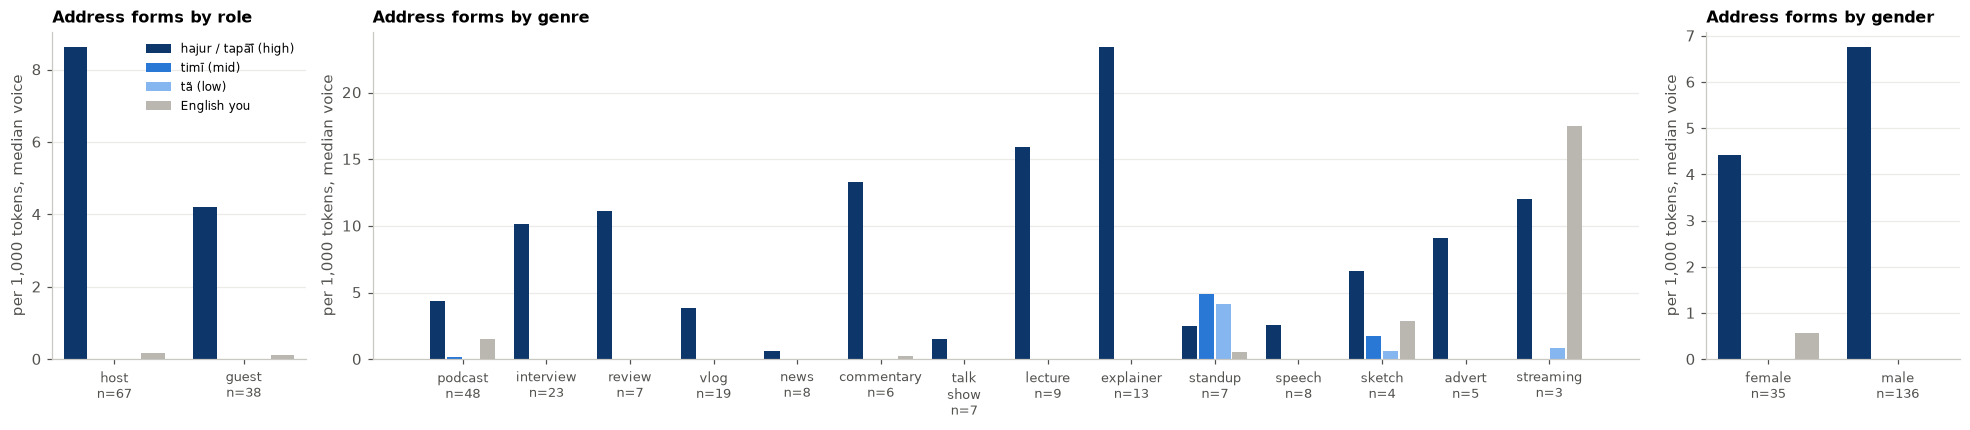

,high / 1000,of which bare hajur,mid / 1000,low / 1000,you / 1000
genre,,,,,
podcast,7.73,2.37,1.73,0.26,5.55
interview,20.61,8.29,1.00,0.54,0.18
review,12.33,0.63,0.02,0.00,1.66
vlog,17.02,1.00,0.28,0.65,1.55
news,1.28,0.07,0.13,0.03,0.24
commentary,14.33,0.07,0.00,0.00,0.39
talk_show,12.83,0.52,2.23,0.31,6.18
lecture,17.45,0.49,0.00,0.00,0.85
explainer,18.84,0.36,0.30,0.00,2.43


the low form tã appears in 38 of 171 voices (podcast 13, interview 10, standup 6, streaming 3, vlog 2, sketch 2, talk show 1, news 1); 60 voices use timī at all


In [8]:
HON_COLS = ["hon high / 1000", "hon mid / 1000", "hon low / 1000", "you / 1000"]
HON_COLORS = [RAMP[4], RAMP[2], RAMP[0], GREY]
HON_LABELS = ["hajur / tapāī̃ (high)", "timī (mid)", "tã (low)", "English you"]
by_groups = (("role", ROLES), ("genre", GENRE_GROUPS), ("gender", GENDERS))
fig, axes = plt.subplots(1, 3, figsize=(18, 4), gridspec_kw={"width_ratios": [len(order) + 1 for _, order in by_groups]})
for ax, (by, order) in zip(axes, by_groups):
    g = VV[VV[by].isin(order)].groupby(by)[HON_COLS].median().reindex(order)
    n = VV[VV[by].isin(order)].groupby(by).size().reindex(order, fill_value=0).astype(int)
    x = np.arange(len(order))
    for i, (col, color, label) in enumerate(zip(HON_COLS, HON_COLORS, HON_LABELS)):
        ax.bar(x + (i - 1.5) * 0.2, g[col], 0.18, color=color, label=label)
    ax.set_xticks(x, [f"{pretty(o).replace(' ', chr(10))}\nn={n[o]}" for o in order], fontsize=8.5)
    ax.set(title=f"Address forms by {by}", ylabel="per 1,000 tokens, median voice")
    ax.grid(axis="x", visible=False)
axes[0].legend(fontsize=8)
fig.tight_layout()
save(fig, "04_address_forms")
plt.show()

hon = usable.groupby("genre")[["hon_high", "hon_mid", "hon_low", "hajur_bare", "en_you", "tokens"]].sum().reindex(GENRES)
hon_t = pd.DataFrame({
    "high / 1000": 1000 * hon.hon_high / hon.tokens, "  of which bare hajur": 1000 * hon.hajur_bare / hon.tokens,
    "mid / 1000": 1000 * hon.hon_mid / hon.tokens, "low / 1000": 1000 * hon.hon_low / hon.tokens, "you / 1000": 1000 * hon.en_you / hon.tokens,
})
display(hon_t)
lo = VV[VV["hon low / 1000"] > 0]
print(f"the low form tã appears in {len(lo)} of {len(VV)} voices ({', '.join(f'{pretty(g)} {n}' for g, n in lo.genre.value_counts().items())}); "
      f"{(VV['hon mid / 1000'] > 0).sum()} voices use timī at all")

## 7. Discourse markers

Two closed lists. Nepali: *chāhī̃* (topic marker), *ni*, *hai*, *ani*, *haina* (tag), *bhaneko*
("that is"), *matlab*, *khai*, *la*. English: *so, like, actually, basically, okay, right, yeah,
literally, obviously, anyway, you know, I mean*. The English share of a voice's markers is a
sharper index of bilingual discourse than the English share of its words: *so* is the single
most frequent English token in the corpus, ahead of *the*, and a speaker who structures Nepali
talk with *so* and *like* is doing something different from one who names a *phone*.

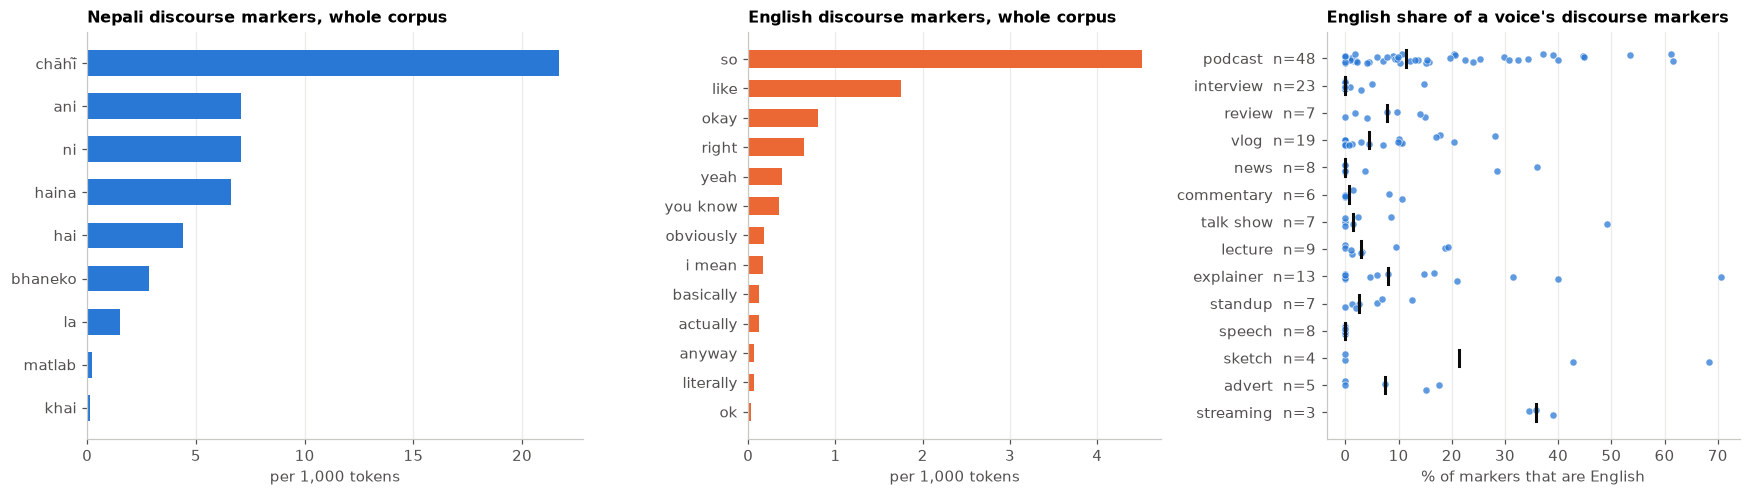

voices  dm ne / 1000  dm en / 1000  en dm share %  p (en dm share)
gender female       35.00         49.06          4.09           6.90             0.52
       male        136.00         45.83          1.27           2.75             0.52
age    20_39       103.00         57.45          3.37           6.02             0.09
       40_59        48.00         33.39          0.13           0.30             0.09
       60_79        15.00         40.93          0.34           0.79             0.09
       80_plus       4.00         39.86          0.00           0.00             0.09
role   host         67.00         43.15          0.97           2.98             0.89
       guest        38.00         41.40          1.52           2.49             0.89
genre  podcast      48.00         59.38          7.87          11.42             0.00
       interview    23.00         44.92          0.00           0.00             0.00
       review        7.00         64.21          2.93           7.74             0.00
       vlog         19.00         71.95          5.83           4.44             0.00
       news          8.00          1.18          0.00           0.00             0.00
       commentary    6.00         51.61          0.49           0.75             0.00
       talk_show     7.00         63.25          1.34           1.39             0.00
       lecture       9.00         49.36          1.27           2.86             0.00
       explainer    13.00         38.79          3.37           8.00             0.00
       standup       7.00         52.57          1.43           2.65             0.00
       speech        8.00          6.70          0.00           0.00             0.00
       sketch        4.00         16.27          4.97          21.43             0.00
       advert        5.00         56.68          4.93           7.41             0.00
       streaming     3.00         43.15         24.10          35.77             0.00

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6), gridspec_kw={"width_ratios": [1.2, 1, 1]})
ax = axes[0]
dm_ne = usable[[c for c in usable.columns if c.startswith("dmne_")]].sum().sort_values()
dm_ne.index = [c.replace("dmne_", "") for c in dm_ne.index]
ax.barh(dm_ne.index, 1000 * dm_ne / usable.tokens.sum(), color=RAMP[2], height=0.6)
ax.set(title="Nepali discourse markers, whole corpus", xlabel="per 1,000 tokens")
ax.grid(axis="y", visible=False)

en_dm = Counter()
for text in usable.text:
    low = [w.strip(EDGE).lower() for w in text.split()]
    en_dm.update(w for w in low if w in DM_EN)
    en_dm.update(" ".join(b) for b in zip(low, low[1:]) if b in DM_EN_BIGRAM)
ax = axes[1]
s = pd.Series(en_dm).sort_values()
ax.barh(s.index, 1000 * s / usable.tokens.sum(), color=SLOTS[1], height=0.6)
ax.set(title="English discourse markers, whole corpus", xlabel="per 1,000 tokens")
ax.grid(axis="y", visible=False)

ax = axes[2]
strip(ax, VV, "en dm share %", "genre", GENRE_GROUPS, GENRE_COLOR, title="English share of a voice's discourse markers", xlabel="% of markers that are English", compact=True)
fig.tight_layout()
save(fig, "05_discourse_markers")
plt.show()
dm_tab = {}
for by, order in (("gender", GENDERS), ("age", AGES), ("role", ROLES), ("genre", GENRE_GROUPS)):
    for g in order:
        sub = VV[VV[by] == g]
        if len(sub) >= 3:
            dm_tab[(by, g)] = {"voices": len(sub), "dm ne / 1000": sub["dm ne / 1000"].median(), "dm en / 1000": sub["dm en / 1000"].median(),
                               "en dm share %": sub["en dm share %"].median(), "p (en dm share)": test(VV, "en dm share %", by, order)}
display(pd.DataFrame(dm_tab).T.round(2))

## 8. Accommodation between host and guest

Speech accommodation predicts that a host's mixing moves toward the guest's. The corpus can test
it two ways. Across episodes: each episode with a resolved host voice and at least one guest
voice gives one (host, guest) pair of English shares. Within a host: the series hosts appear in
many episodes, so for each of them the correlation between their own English share and their
guest's, episode by episode, controls for the host entirely. Both need 100+ attributed tokens
per speaker per episode.

34 episodes with one resolved host and 42 resolved guests


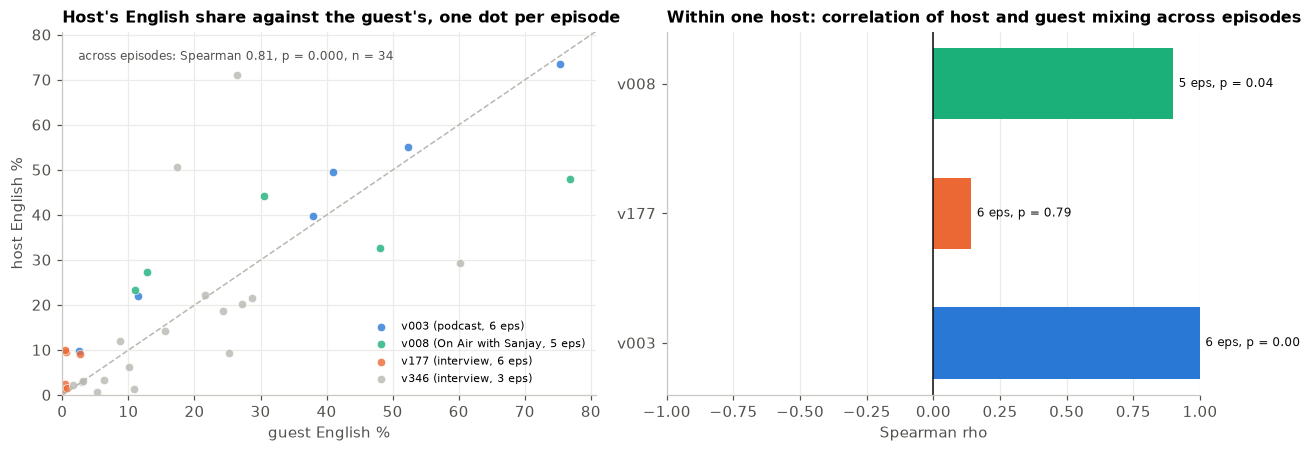

,host,show,episodes,host mean %,host sd %,guest sd %,Spearman,p
0,v003,podcast,6,41.66,23.11,26.70,1.00,0.00
2,v177,interview,6,5.71,4.26,0.92,0.14,0.79
1,v008,On Air with Sanjay,5,35.13,10.68,27.42,0.90,0.04


In [10]:
ep_voice = attributed.groupby(["episode", "speaker"]).agg(tokens=("tokens", "sum"), lat=("lat", "sum"), mixed=("mixed", "sum"))
ep_voice = ep_voice[ep_voice.tokens >= 100]
ep_voice["english %"] = 100 * (ep_voice.lat + ep_voice.mixed) / ep_voice.tokens
ep_voice["role"] = [ROLE.get((e, v)) for e, v in ep_voice.index]
pairs = []
for e, sub in ep_voice.groupby(level=0):
    hosts_, guests_ = sub[sub.role == "host"], sub[sub.role == "guest"]
    if len(hosts_) == 1 and len(guests_) >= 1:
        pairs.append({"episode": e, "host": hosts_.index[0][1], "host %": hosts_["english %"].iloc[0],
                      "guest %": np.average(guests_["english %"], weights=guests_.tokens), "guests": len(guests_), "show": show(e)})
pairs = pd.DataFrame(pairs)
print(f"{len(pairs)} episodes with one resolved host and {pairs.guests.sum()} resolved guests")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
ax = axes[0]
host_ids = pairs.host.value_counts()
host_color = {h: SLOTS[i] if i < 3 else GREY for i, h in enumerate(host_ids.index)}
for h, sub in pairs.groupby("host"):
    ax.scatter(sub["guest %"], sub["host %"], s=30, color=host_color[h], alpha=0.8, edgecolor="white", linewidth=0.5,
               label=f"{h} ({sub.show.iloc[0]}, {len(sub)} eps)" if len(sub) >= 3 else None)
lim = [0, max(pairs["guest %"].max(), pairs["host %"].max()) * 1.05]
ax.plot(lim, lim, color=GREY, lw=1, ls="--")
ax.set(title="Host's English share against the guest's, one dot per episode", xlabel="guest English %", ylabel="host English %", xlim=lim, ylim=lim)
ax.legend(fontsize=7.5, loc="lower right")
rho_all = stats.spearmanr(pairs["guest %"], pairs["host %"])
ax.text(0.03, 0.95, f"across episodes: Spearman {rho_all[0]:.2f}, p = {rho_all[1]:.3f}, n = {len(pairs)}", transform=ax.transAxes, va="top", fontsize=8, color=MUTED)

ax = axes[1]
within = []
for h, sub in pairs.groupby("host"):
    if len(sub) >= 5:
        r = stats.spearmanr(sub["guest %"], sub["host %"])
        within.append({"host": h, "show": sub.show.iloc[0], "episodes": len(sub), "host mean %": sub["host %"].mean(), "host sd %": sub["host %"].std(),
                       "guest sd %": sub["guest %"].std(), "Spearman": r[0], "p": r[1]})
within = pd.DataFrame(within).sort_values("episodes", ascending=False)
if len(within):
    ax.barh(within.host, within.Spearman, color=[host_color[h] for h in within.host], height=0.55)
    for y, r in enumerate(within.itertuples()):
        ax.text(r.Spearman + (0.02 if r.Spearman >= 0 else -0.02), y, f"{r.episodes} eps, p = {r.p:.2f}", va="center", ha="left" if r.Spearman >= 0 else "right", fontsize=8, color=INK)
    ax.axvline(0, color=INK, lw=1)
    ax.set(title="Within one host: correlation of host and guest mixing across episodes", xlabel="Spearman rho", xlim=(-1, 1))
    ax.grid(axis="y", visible=False)
fig.tight_layout()
save(fig, "06_accommodation")
plt.show()
display(within.round(2))

## 9. Turn-taking by gender pairing

Crosstalk and hand-overs are measured on every clip (D77, D78) but carry no speaker, so the
question the corpus can answer is about the *composition* of a conversation, not who interrupts
whom: is a mixed-gender episode more or less overlapped than a same-gender one? Only episodes
whose every voice has a resolved gender count. Composition is a property of the episode, so n is
episodes, and an episode with a single voice falls out.

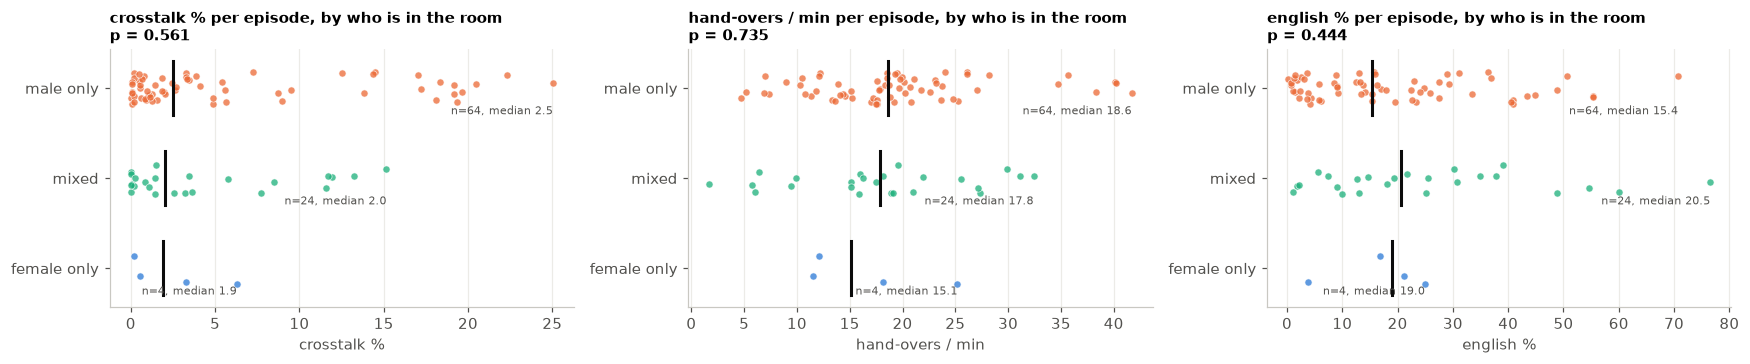

composition,one voice,male only,mixed,female only
episodes,250,64,24,4


In [11]:
ep_rows = []
for e, sub in usable.groupby("episode"):
    voices = [v for v in set(sub.voice.dropna()) if voice_talk[v] > 0]
    genders = {SPK.gender[v] for v in voices}
    if not voices or "unresolved" in genders or len(voices) < 2:
        comp = "unresolved" if "unresolved" in genders or not voices else "one voice"
    else:
        comp = "mixed" if len(genders) == 2 else f"{genders.pop()} only"
    ep_rows.append({"episode": e, "genre": sub.genre.iloc[0], "show": show(e), "voices": len(voices), "composition": comp,
                    "minutes": sub.duration.sum() / 60, "crosstalk %": 100 * sub.overlap_s.sum() / sub.duration.sum(),
                    "hand-overs / min": 60 * sub.turn_changes.sum() / sub.duration.sum(),
                    "english %": 100 * (sub.lat.sum() + sub.mixed.sum()) / sub.tokens.sum()})
EP = pd.DataFrame(ep_rows).set_index("episode")
COMPS = ["male only", "mixed", "female only"]
COMP_COLOR = {"male only": GENDER_COLOR["male"], "mixed": GENDER_COLOR["mixed"], "female only": GENDER_COLOR["female"]}
conv = EP[EP.composition.isin(COMPS)]
fig, axes = plt.subplots(1, 3, figsize=(16, 3.4))
for ax, col in zip(axes, ("crosstalk %", "hand-overs / min", "english %")):
    strip(ax, conv, col, "composition", COMPS, COMP_COLOR, title=f"{col} per episode, by who is in the room", xlabel=col)
    ax.set_title(f"{col} per episode, by who is in the room\np = {test(conv, col, 'composition', COMPS):.3f}", fontsize=9.5)
fig.tight_layout()
save(fig, "07_pairing")
plt.show()
display(EP.composition.value_counts().rename("episodes").to_frame().T)

## 10. What a comparison could detect

The paper's comparisons are between groups of voices. With the voices there are, and the
spread between voices that the corpus shows, the minimum difference in English share (percentage
points) a two-sample test would detect at 80% power and α = 0.05 is given for each split, next
to the difference actually observed. The last column is how many voices *per group* would be
needed to detect the target in the column before it: five points of English share, or one
switch per hundred tokens. This is a t-test power calculation on a quantity that is not normal, so
it is a guide to scale, not a promise.

In [12]:
def mde(n1, n2, sd, alpha=0.05, power=0.8):
    df = n1 + n2 - 2
    return (stats.t.ppf(1 - alpha / 2, df) + stats.t.ppf(power, df)) * sd * np.sqrt(1 / n1 + 1 / n2)


def n_for(delta, sd, alpha=0.05, power=0.8):
    z = stats.norm.ppf(1 - alpha / 2) + stats.norm.ppf(power)
    return int(np.ceil(2 * (z * sd / delta) ** 2))


g1, g2 = VV.genre.value_counts().index[:2]  # the two genres with the most voices
power_rows = []
for metric, target in (("english %", 5.0), ("switches / 100", 1.0)):
    for by, a, b, frame, label in (("gender", "female", "male", VV, "female vs male"), ("gender", "female", "male", pod, "female vs male, podcasts only"),
                                   ("age", "20_39", "40_59", VV, "20-39 vs 40-59"), ("age", "40_59", "60_79", VV, "40-59 vs 60-79"),
                                   ("role", "host", "guest", VV, "host vs guest"), ("genre", g1, g2, VV, f"{pretty(g1)} vs {pretty(g2)}")):
        x, y = frame.loc[frame[by] == a, metric], frame.loc[frame[by] == b, metric]
        if len(x) < 2 or len(y) < 2:
            continue
        sd = np.sqrt(((len(x) - 1) * x.var() + (len(y) - 1) * y.var()) / (len(x) + len(y) - 2))
        power_rows.append({"metric": metric, "comparison": label, "n": f"{len(x)} vs {len(y)}", "pooled sd": sd, "observed diff": x.mean() - y.mean(),
                           "detectable diff": mde(len(x), len(y), sd), "target": target, "n/group for target": n_for(target, sd)})
POWER = pd.DataFrame(power_rows).set_index(["metric", "comparison"])
display(POWER.round(2))

n  pooled sd  observed diff  detectable diff  target  n/group for target
metric         comparison                                                                                                     
english %      female vs male                 35 vs 136      16.19          -1.90             8.64    5.00                 165
               female vs male, podcasts only   14 vs 34      18.14          -3.99            16.49    5.00                 207
               20-39 vs 40-59                 103 vs 48      15.81           4.62             7.79    5.00                 157
               40-59 vs 60-79                  48 vs 15      20.10           2.18            16.92    5.00                 254
               host vs guest                   67 vs 38      17.34           0.25             9.96    5.00                 189
               podcast vs interview            48 vs 23      15.64          22.08            11.27    5.00                 154
switches / 100 female vs male                 35 vs 136      11.28          -0.10             6.03    1.00                1999
               female vs male, podcasts only   14 vs 34       9.85           0.70             8.95    1.00                1523
               20-39 vs 40-59                 103 vs 48      10.21           9.37             5.03    1.00                1636
               40-59 vs 60-79                  48 vs 15       9.81           3.00             8.26    1.00                1511
               host vs guest                   67 vs 38      11.22           4.10             6.44    1.00                1976
               podcast vs interview            48 vs 23       9.06          13.41             6.53    1.00                1290

## 11. Verdict

Printed from the frames above, so a rerun on a newer export rewrites it.

In [13]:
def known(field):
    k = VV[field] != "unresolved"
    return f"{k.sum()} of {len(VV)} voices ({VV.talk_min[k].sum() / VV.talk_min.sum():.0%} of their speech)"


def small(p):
    return "< 0.0001" if p < 0.0001 else f"= {p:.4f}" if p < 0.01 else f"= {p:.2f}"


g_n = VV.gender.value_counts()
a_n = VV.age.value_counts()
r_n = VV.role.value_counts()
lead = attributed.groupby(["genre", "speaker"]).tokens.sum()
lead = lead.groupby(level=0).max() / lead.groupby(level=0).sum()  # the largest voice's share of a genre's attributed tokens
p_gender = POWER.loc[("english %", "female vs male")]
p_gender_pod = POWER.loc[("english %", "female vs male, podcasts only")] if ("english %", "female vs male, podcasts only") in POWER.index else None
lines = [
    f"UNITS     {len(SPK)} voices in {usable.episode.nunique()} episodes; {len(VV)} voices carry {MIN_TOKENS}+ attributed tokens and are the usable n.",
    f"RECORDED  gender known for {known('gender')}; age {known('age')}; role {known('role')}.",
    f"          cells: " + ", ".join(f"{g}/{pretty(a)} {int(grid.loc[(g, a), 'voices'])}" for g in GENDERS for a in AGES) + " voices (any talk time).",
    f"          women hold {f_in.min():.0%} ({pretty(f_in.idxmin())}) to {f_in.max():.0%} ({pretty(f_in.idxmax())}) of the gender-known speech by genre: gender and genre are confounded.",
    f"GENRES    {len(GENRE_GROUPS)} of {len(GENRES)} genres hold 3+ usable voices: " + ", ".join(f"{pretty(g)} {(VV.genre == g).sum()}" for g in GENRE_GROUPS) + ".",
    f"          one voice holds over half of the attributed tokens in: " + (", ".join(f"{pretty(g)} ({lead[g]:.0%})" for g in GENRES if lead.get(g, 0) > 0.5) or "no genre") + ".",
    f"REFUSED   dialect/region and name (D56). ABSENT: education, occupation, L1, ethnicity, diaspora status. STORED, NOT EXPORTED: upload date and channel.",
    f"DERIVED   English share, switch rate, run lengths, integrated stems, function-word share, address forms, discourse markers, accommodation, pairing: all computed from the reference.",
    f"MIXING    median voice {VV['english %'].median():.0f}% English, {VV['switches / 100'].median():.1f} switches / 100 tokens; "
    f"{100 * usable.run_tok_1.sum() / tot_runs:.0f}% of in-sentence English is a single word (insertion), {100 * usable.run_tok_6.sum() / tot_runs:.0f}% runs of 6+ (alternation).",
    f"          by gender p = {test(VV, 'english %', 'gender', GENDERS):.2f} (n {g_n.get('female', 0)} vs {g_n.get('male', 0)}); "
    f"podcasts only p = {test(pod, 'english %', 'gender', GENDERS):.2f}; by role p = {test(VV, 'english %', 'role', ROLES):.2f}.",
    f"          by age p {small(test(VV, 'english %', 'age', AGES))}, but podcasts only p {small(test(pod, 'english %', 'age', AGES))}: older voices sit in the Nepali-only genres. "
    f"Switch rate by age: p {small(test(VV, 'switches / 100', 'age', AGES))}, podcasts only p {small(test(pod, 'switches / 100', 'age', AGES))}.",
    f"ADDRESS   high forms {hon_t['high / 1000'].mean():.1f} / 1000 tokens across genres; tã in {len(lo)} voices; timī in {(VV['hon mid / 1000'] > 0).sum()}.",
    f"MARKERS   median voice: {VV['en dm share %'].median():.0f}% of its discourse markers are English; by genre p = {test(VV, 'en dm share %', 'genre', GENRES):.3f}.",
    f"ACCOMMOD. {len(pairs)} host-guest episodes, across-episode Spearman {rho_all[0]:.2f} (p = {rho_all[1]:.2f}); "
    + "; ".join(f"{r.host} within-host rho {r.Spearman:.2f} over {r.episodes} eps" for r in within.itertuples()) + ".",
    f"PAIRING   episodes by composition: " + ", ".join(f"{c} {int((EP.composition == c).sum())}" for c in COMPS) + f"; crosstalk p = {test(conv, 'crosstalk %', 'composition', COMPS):.2f}.",
    f"POWER     gender split detects a {p_gender['detectable diff']:.0f}-point English-share difference (observed {p_gender['observed diff']:+.0f}); "
    f"a 5-point difference needs {int(p_gender['n/group for target'])} voices per group at the observed spread.",
]
if p_gender_pod is not None:
    lines.append(f"          within podcasts: detects {p_gender_pod['detectable diff']:.0f} points with n {p_gender_pod['n']}.")
lines += [
    "SUPPORTS  a descriptive paper on the *form* of Nepali-English mixing (insertion vs alternation, integration, markers, address) with speaker-level variation by role and genre;",
    "          an accommodation study within the recurring hosts; a register contrast between the genres that hold enough voices (GENRES).",
    "          a genre that one voice dominates illustrates a register but cannot stand for one.",
    "DOES NOT  support a Labovian social-stratification study: no region, class, education or L1; gender and age are both confounded with genre,",
    f"          and of the {len(VV)} usable voices {int((VV.gender == 'female').sum())} are women and {int(((VV.gender == 'female') & VV.age.isin(['60_79', '80_plus'])).sum())} are women over 60;",
    "          any gender or age claim needs more female and older voices inside one genre, not more hours of the same speakers.",
    "CAVEAT    references are lightly checked fusions of three recognisers (EDA); demographics are the annotator's reading of a public episode, not self-report.",
]
print("\n".join(lines))

UNITS     358 voices in 342 episodes; 171 voices carry 300+ attributed tokens and are the usable n.
RECORDED  gender known for 171 of 171 voices (100% of their speech); age 171 of 171 voices (100% of their speech); role 105 of 171 voices (76% of their speech).
          cells: female/under 20 2, female/20-39 66, female/40-59 21, female/60-79 2, female/80 plus 0, male/under 20 1, male/20-39 166, male/40-59 77, male/60-79 17, male/80 plus 5 voices (any talk time).
          women hold 0% (lecture) to 74% (review) of the gender-known speech by genre: gender and genre are confounded.
GENRES    14 of 17 genres hold 3+ usable voices: podcast 48, interview 23, review 7, vlog 19, news 8, commentary 6, talk show 7, lecture 9, explainer 13, standup 7, speech 8, sketch 4, advert 5, streaming 3.
          one voice holds over half of the attributed tokens in: review (72%), commentary (54%), audiobook (62%), sketch (57%), streaming (54%).
REFUSED   dialect/region and name (D56). ABSENT: education, 